In [1]:
import numpy as np
import pandas as pd

# =====================
# Plotting
# =====================
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import seaborn as sns

# =====================
# SciPy / Stats
# =====================
from scipy.stats import norm
import statsmodels.api as sm
import statsmodels.formula.api as smf

# =====================
# sklearn – model selection
# =====================
from sklearn.model_selection import train_test_split

# =====================
# sklearn – models
# =====================
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# =====================
# sklearn – metrics
# =====================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    r2_score,
    mean_squared_error,
)

# =====================
# Utilities
# =====================
from itertools import combinations, product
from tqdm import tqdm

In [4]:
#Plot parameters
plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.labelsize": 16,     # x/y labels
    "axes.titlesize": 16,     # subplot titles
    "xtick.labelsize": 14,    # x-tick labels
    "ytick.labelsize": 14,    # y-tick labels
    "legend.fontsize": 14     # legend
})

In [2]:
def def_lambdaSystem_random(N, lambda_min, lambda_max):
    lambdaMatrix = np.random.uniform(low = lambda_min, high = lambda_max, size =(N, N)) 
    for i in range(0, N):
        lambdaMatrix[i, i] = 0  # set diagonal to 0
    return lambdaMatrix

#-----------------------------------------------------------------------------------------------------------------------------------------------
def plot_lambdaMatrices(lambdaMatrix, lambdaInvader):
    fig = plt.figure(figsize=(3, 3.7))
    gs = GridSpec(2, 2, width_ratios=[1, 0.08], height_ratios=[1, 1], wspace=0.1)

    # Axes for matrices (same width enforced by GridSpec)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    cbar_ax = fig.add_subplot(gs[:, 1])

    # Plot both matrices using the *same* normalization
    vmin = min(lambdaMatrix.min(), lambdaInvader.min())
    vmax = max(lambdaMatrix.max(), lambdaInvader.max())

    # Plot system matrix
    im1 = ax1.imshow(lambdaMatrix, cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
    ax1.set_xlabel("Resident j")
    ax1.set_ylabel("Invader i")
    ax1.set_title(r'$\Lambda = (\lambda_i^j)$')
    ax1.set_xticks(range(lambdaMatrix.shape[1]))
    ax1.set_xticklabels(range(1, lambdaMatrix.shape[1] + 1))

    # Plot invader array
    im2 = ax2.imshow(lambdaInvader, cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
    ax2.set_xlabel("Resident i")
    ax2.set_title(r'$\lambda^i_\text{inv}$')
    ax2.set_xticks(range(lambdaInvader.shape[1]))
    ax2.set_xticklabels(range(1, lambdaInvader.shape[1] + 1))
    ax2.set_yticks([])
    ax2.set_ylabel("")

    # ONE colorbar shared by both axes
    cbar = fig.colorbar(im1, cax=cbar_ax)

    plt.show()

#-----------------------------------------------------------------------------------------------------------------------------------------------
def def_lambdaInvader_random(N, lambda_min, lambda_max):
    return np.random.uniform(low = lambda_min, high = lambda_max, size =(1, N)) 

#-----------------------------------------------------------------------------------------------------------------------------------------------
def r_invader(z0, lambdaSystem, lambdaInvader): 
    Q = np.dot(z0.T, np.dot(lambdaSystem, z0))
    r = np.dot(lambdaInvader, z0) - Q
    return r[0]

#-----------------------------------------------------------------------------------------------------------------------------------------------
def dataframe_nWomen(N, lambdaSystem, lambdaInvader, nWomen, stdev_noise=0):
    columns = [f'z{i+1}' for i in range(N)] + ['r']
    df = pd.DataFrame(columns=columns)
    for i in range(nWomen):
        z0 = np.random.dirichlet(np.ones(N))  # z_1, ..., z_N
        r = r_invader(z0, lambdaSystem, lambdaInvader)  # r_inv^1, ..., r_inv^N
        noise = np.random.normal(loc=0.0, scale=stdev_noise, size=r.shape)  # small Gaussian noise
        #r_noisy = r + noise              # if stdev_noise=0, then r_noisy = r
        r_noisy = r * (1 + noise)
        z0_flat = z0.flatten().tolist()
        df.loc[i] = z0_flat + [r_noisy]  # Appending row
    return df

#-----------------------------------------------------------------------------------------------------------------------------------------------
def generate_data(seed, N, lambda_min, lambda_max, nWomen, stdev_noise):
    np.random.seed(seed)
    lambdaSystem = def_lambdaSystem_random(N, lambda_min, lambda_max)
    lambdaInvader = def_lambdaInvader_random(N, lambda_min, lambda_max)
    df = dataframe_nWomen(N, lambdaSystem, lambdaInvader, nWomen, stdev_noise)
    return lambdaSystem, lambdaInvader, df

#-----------------------------------------------------------------------------------------------------------------------------------------------
def plot_dataset(df_melted):
    sns.lmplot(x="z_value", y="r", hue="Species", data=df_melted, fit_reg=False, height=3, aspect=1.5, scatter_kws={"s": 20})
    plt.xlabel("Initial frequencies")
    plt.ylabel(r"$r_{\ inv}$")
    plt.title("Initial invader growth ratio vs system species frequencies")
    plt.show()

#-----------------------------------------------------------------------------------------------------------------------------------------------
def residual_plot(N, r_pred, residuals, e_linear, e_quadratic, sign_linear, sign_quadratic, quadratic_vars, error = "relative"):
    fig = plt.figure(figsize=(N*0.8, 4.5))  # increase height for two rows
    gs = GridSpec(2, 2, height_ratios=[1, 1.2], width_ratios=[1, 1], figure=fig)
    # Residual plot
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(r_pred, residuals, s=10)
    ax1.axhline(0, color='red', linestyle='--')
    ax1.set_xlabel("Fitted values")
    ax1.set_ylabel("Residuals")

    # Colors
    colors_linear = ['green' if b==1 else 'red' for b in sign_linear]
    colors_quadratic = ['green' if b==1 else 'red' for b in sign_quadratic]

    # Linear coefficients
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(range(1,N+1), e_linear, color = colors_linear)
    ax2.set_title(r"$\lambda_\text{inv}^i$")
    #ax2.set_title("Linear coefficients")
    ax2.set_xlabel("i")
    ax2.set_xticks(range(1,N+1))
    ax2.set_xticklabels([f"{i}" for i in range(1,N+1)])

    # Quadratic coefficients
    ax3 = fig.add_subplot(gs[1, :])      # full row
    ax3.bar(range(len(quadratic_vars)), e_quadratic, color = colors_quadratic)
    ax3.set_title(r"$\tilde{\lambda}_{ij}$")
    #ax3.set_title("Quadratic coefficients")
    ax3.set_xlabel("(i,j)")
    ax3.set_xticks(range(len(quadratic_vars)))
    ax3.set_xticklabels([f"({i+1},{j+1})" for i in range(N) for j in range(i + 1, N)],rotation=45, ha="right")
    
    if error == 'relative':
        ax2.set_ylabel(r"$|e_{rel}|$") 
        ax3.set_ylabel(r"$|e_{rel}|$") 
    elif error == 'absolute':
        ax2.set_ylabel(r"$|e_{abs}|$")
        ax3.set_ylabel(r"$|e_{abs}|$") 
    elif error == 'SE':
        ax2.set_ylabel("Squared Error") 
        ax3.set_ylabel("Squared Error")
    legend_elements = [Patch(facecolor='green', label='Correct sign'),
                       Patch(facecolor='red', label='Wrong sign')]
    ax2.legend(handles=legend_elements, fontsize=8)
    ax3.legend(handles=legend_elements, fontsize=8)

    plt.tight_layout()
    plt.show()


#-----------------------------------------------------------------------------------------------------------------------------------------------
def regression_OLS(N, df, lambdaSystem, lambdaInvader, error = 'relative', print_df=False, plot_df=False, print_results=True, plot_residuals=True):
    """
    Takes the frequencies z_i and the corresponding r_inv (artificially computed from the RE) as an input, performs a linear regression with interaction 
    terms, and outputs the parameters of the RE (array Lambda_inv and matrix Lambda summed up across the diagonal). 
    Without intercept term.
    """
    # Print and plot dataframe
    if print_df is True:
        df.head()
    if plot_df is True:
        df_melted = df.melt(id_vars=['r'], var_name='Species', value_name='z_value')  # join the z_i's
        plot_dataset(df_melted)

    # Remove intercept adding '-1' to the formula
    linear_vars    = [f'z{i+1}' for i in range(N)]
    quadratic_vars = [f'z{i+1}:z{j+1}' for i in range(N) for j in range(i+1, N)]
    formula = 'r ~ ' + ' + '.join(linear_vars) + ' + ' + ' + '.join(quadratic_vars) + '-1'
    model = smf.ols(formula=formula, data=df)    # library that contains cross-sectional statistical models and methods
    results = model.fit()  
    if print_results is True:
        print("Formula: ", formula, "\n")
        print(results.summary())

    # Plot model performance metrics 
    if plot_residuals is True:
        residuals = results.resid
        fitted = results.fittedvalues
        params = results.params
        target_linear       = lambdaInvader[0]
        target_quadratic    = - np.array([lambdaSystem[i, j] + lambdaSystem[j, i] for i in range(N) for j in range(i+1, N)])
        estimated_linear    = np.array([params.get(var, np.nan) for var in linear_vars])
        estimated_quadratic = np.array([params.get(var, np.nan) for var in quadratic_vars]) 
        sign_linear = (np.sign(estimated_linear) == np.sign(target_linear)).astype(int)
        sign_quadratic = (np.sign(estimated_quadratic) == np.sign(target_quadratic)).astype(int)
        if error == 'relative':
            e_linear = np.abs((estimated_linear - target_linear) / target_linear)
            e_quadratic = np.abs((estimated_quadratic - target_quadratic) / target_quadratic)
        elif error == 'absolute':
            e_linear    = np.abs(estimated_linear - target_linear)      
            e_quadratic = np.abs(estimated_quadratic - target_quadratic)
        elif error == 'SE':
            e_linear = np.abs(estimated_linear - target_linear)**2
            e_quadratic = np.abs(estimated_quadratic - target_quadratic)**2
        residual_plot(N, fitted, residuals, e_linear, e_quadratic, sign_linear, sign_quadratic, quadratic_vars, error)

    return results



#-----------------------------------------------------------------------------------------------------------------------------------------------
def discretize_r(df, n_levels):
    """
    Divides the r values in 11 equispaced levels, and assigns to them the level center values (more representative).
    """
    # Find the range of r_inv
    r = df.iloc[:, -1]
    r_min = r.min()
    r_max = r.max()
    # Create 11 levels (~ 0 to 10 in terms of Nugent score)
    classes = np.linspace(r_min, r_max, num = n_levels+1)  # 12 edges -> 11 intervals
    # Assign each r value to a level (index)
    r_discrete_idx = pd.cut(r, bins=classes, labels=False, include_lowest=True)
    # Map each bin index to the corresponding level center (midpoint)
    level_centers = (classes[:-1] + classes[1:]) / 2  # midpoints of each bin
    r_discrete= level_centers[r_discrete_idx.values]  # replace idx by center value
    # Actualize df
    df.iloc[:, -1] = r_discrete   # values
    #df = df.rename(columns={'r': 'r_discrete'})
    return df, classes

#-----------------------------------------------------------------------------------------------------------------------------------------------

# Threshold to exclude tiny coefficients
def apply_threshold(estimated, target, tau):
    mask = np.abs(target) >= tau
    return estimated[mask], target[mask]
    
#-----------------------------------------------------------------------------------------------------------------------------------------------


def alpha_search_nsystems(nSystems, N, lambda_min, lambda_max, nWomen, stdev_noise, alpha_min, alpha_max, alpha_step, levels, error, n_splits):
    alpha_vals = np.arange(alpha_min, alpha_max + alpha_step, alpha_step)
    n_alpha = len(alpha_vals)

    # Matrius de resultats
    e_lin_all     = np.zeros((nSystems, n_alpha))
    e_quad_all    = np.zeros((nSystems, n_alpha))
    sign_lin_all  = np.zeros((nSystems, n_alpha))
    sign_quad_all = np.zeros((nSystems, n_alpha))
    r2_all        = np.zeros((nSystems, n_alpha))
    mse_all       = np.zeros((nSystems, n_alpha))
    acc_all       = np.zeros((nSystems, n_alpha))

    # Loop over different women (systems)
    for s in tqdm(range(nSystems), desc="Systems computed"):

        # Generate system
        lambdaSystem, lambdaInvader, df = generate_data(s, N, lambda_min, lambda_max, nWomen, stdev_noise)
        df_discrete, classes_bins = discretize_r(df, levels)

        # ==== LOOP SOBRE ALPHA ====
        for j, alpha in enumerate(alpha_vals):

            model = regression_Ridge(N, df_discrete, alpha, lambdaSystem, lambdaInvader, error, False, False, False, False)

            accuracy = run_multiple_evaluations_with_metrics(df_discrete, alpha, classes_bins, n_splits, test_size=0.1)

            e_lin_all[s, j]  = np.mean(model["error_linear"])     # mean over all linear coefficients whithin a system
            e_quad_all[s, j] = np.mean(model["error_quadratic"])  
            sign_lin_all[s, j]  = np.mean(model["sign_linear"])*100
            sign_quad_all[s, j] = np.mean(model["sign_quadratic"])*100
            r2_all[s, j]     = model["r2"]
            mse_all[s, j]    = model["mse"]
            acc_all[s, j]    = accuracy

    # ==== MITJANES I DESVIACIONS ====
    e_lin_mean     = e_lin_all.mean(axis=0)
    e_quad_mean    = e_quad_all.mean(axis=0)
    sign_lin_mean  = sign_lin_all.mean(axis=0)
    sign_quad_mean = sign_quad_all.mean(axis=0)
    r2_mean        = r2_all.mean(axis=0)
    mse_mean       = mse_all.mean(axis=0)
    acc_mean       = acc_all.mean(axis=0)

    e_lin_std     = e_lin_all.std(axis=0)
    e_quad_std    = e_quad_all.std(axis=0)
    sign_lin_std  = sign_lin_all.std(axis=0)
    sign_quad_std = sign_quad_all.std(axis=0)
    r2_std        = r2_all.std(axis=0)
    mse_std       = mse_all.std(axis=0)
    acc_std       = acc_all.std(axis=0)
    
    #print(acc_mean)
    #print(e_lin_mean)
    #print(e_quad_mean)

    # ==== PLOTS WITH STANDARD DEVIATION BANDS ====
    fig, axes = plt.subplots(1, 4,figsize=(14, 3),constrained_layout=True)
    ax1 = axes[0]              # Main axis (left y-axis)
    ax2 = ax1.twinx()          # Secondary axis (right y-axis)
    
    # R2 and MSE
    line2, = ax2.plot(alpha_vals, r2_mean, color="green", lw=1.4, label=r"$\mathbb{E} [R^2]$")
    ax2.fill_between(alpha_vals, r2_mean - r2_std, r2_mean + r2_std, color="green", alpha=0.2)    
    line1, = ax1.plot(alpha_vals, mse_mean, color="orange", lw=1.4, label=r"$\mathbb{E}$ [MSE]")
    ax1.fill_between(alpha_vals, mse_mean - mse_std, mse_mean + mse_std, color="orange", alpha=0.2)
    ax2.set_ylabel(r"$\mathbb{E}\ [R^2]$")
    ax1.set_ylabel(r"$\mathbb{E}$ [MSE]")
    axes[0].set_xlabel(r"$\alpha$")
    axes[0].legend(handles=[line1, line2])

    # Errors linear + quadratic
    #axes[1].set_ylim(-1, 1)
    axes[1].plot(alpha_vals, e_lin_mean, color="red", lw=1.4, label=r"$\lambda_\text{inv}^i$")
    axes[1].fill_between(alpha_vals, e_lin_mean - e_lin_std, e_lin_mean + e_lin_std, color="red", alpha=0.2)
    axes[1].plot(alpha_vals, e_quad_mean, color="blue", lw=1.4, label=r"$\tilde{\lambda}_{ij}$")
    axes[1].fill_between(alpha_vals, e_quad_mean - e_quad_std, e_quad_mean + e_quad_std, color="blue", alpha=0.2)
    axes[1].set_xlabel(r"$\alpha$")
    if error == 'relative':
        #axes[1].axhline(y=1, color='grey', linestyle='--')
        axes[1].set_ylabel(r"$\mathbb{E}\ [|e_\text{rel}|]$")    
    elif error == 'absolute':
        axes[1].set_ylabel(r"$\mathbb{E}\ [|e_\text{abs}|]$")
    elif error == 'SE':
        axes[1].set_ylabel(r"$\mathbb{E}$ [MSE]") # or Squared Error ??
    axes[1].legend()

    # Sign coincidence
    axes[2].plot(alpha_vals, sign_lin_mean, color="red", lw=1.4, label=r"$\lambda_\text{inv}^i$")
    axes[2].fill_between(alpha_vals, sign_lin_mean - sign_lin_std, sign_lin_mean + sign_lin_std, color="red", alpha=0.2)
    axes[2].plot(alpha_vals, sign_quad_mean, color="blue", lw=1.4, label=r"$\tilde{\lambda}_{ij}$")
    axes[2].fill_between(alpha_vals, sign_quad_mean - sign_quad_std, sign_quad_mean + sign_quad_std, color="blue", alpha=0.2)
    axes[2].set_xlabel(r"$\alpha$")
    axes[2].set_ylabel("Sign coincidence (%)")
    axes[2].legend()


    # Accuracy
    axes[3].plot(alpha_vals, acc_mean, color="gray", lw=1.4)
    axes[3].fill_between(alpha_vals, acc_mean - acc_std, acc_mean + acc_std, color="gray", alpha=0.3)
    axes[3].set_xlabel(r"$\alpha$")
    axes[3].set_ylabel("Accuracy")

    #plt.tight_layout()
    #plt.show()
    results = {
    "alpha": alpha_vals,
    "e_lin_mean": e_lin_mean,
    "e_lin_std": e_lin_std,
    "e_quad_mean": e_quad_mean,
    "e_quad_std": e_quad_std,
    "sign_lin_mean": sign_lin_mean,
    "sign_lin_std": sign_lin_std,
    "sign_quad_mean": sign_quad_mean,
    "sign_quad_std": sign_quad_std,
    "r2_mean": r2_mean,
    "r2_std": r2_std,
    "mse_mean": mse_mean,
    "mse_std": mse_std,
    "acc_mean": acc_mean,
    "acc_std": acc_std,
    "error_type": error
    }
    plt.close(fig)
    return results

#-----------------------------------------------------------------------------------------------------------------------------------------------

def classify_y(y_pred_regression, classes_bins):
    # Assign each y value to a level (index)
    classes_bins[-1] = np.inf
    classes_bins[0] = -np.inf
    y_pred_classes_idx = pd.cut(y_pred_regression, bins=classes_bins, labels=False, include_lowest=True)
    '''# Map each bin index to the corresponding level center (midpoint)
    level_centers = (classes_bins[:-1] + classes_bins[1:]) / 2  # midpoints of each bin
    y_pred_classes = level_centers[y_pred_classes_idx]  # replace idx by center value'''
    return y_pred_classes_idx 

#-----------------------------------------------------------------------------------------------------------------------------------------------
def run_multiple_evaluations_with_metrics(df, alpha, classes_bins, n_splits, test_size=0.1, random_state_seed=42):
    accuracy = []
    y = df["r"].values
    linear_names = [f"z{i+1}" for i in range(N)]
    X = df[linear_names].values
    
    for i in range(n_splits):
        # Step 2: Train/test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state_seed + i)

        # Step 3: Build replicator features: linear + cross-species quadratic
        freqs_linear_train = X_train
        freqs_linear_test = X_test
        cross_terms_train, cross_terms_test = [], []
        quadratic_names = []
        for i, j in combinations(range(X.shape[1]), 2):
            interaction_train = (X_train[:, i] * X_train[:, j]).reshape(-1, 1)
            cross_terms_train.append(interaction_train)
            interaction_test = (X_test[:, i] * X_test[:, j]).reshape(-1, 1)
            cross_terms_test.append(interaction_test)
            quadratic_names.append(f"z{i+1} * z{j+1}")
        quadratic_part_train = np.hstack(cross_terms_train) 
        quadratic_part_test = np.hstack(cross_terms_test) 
        X_freqs_train = np.hstack([freqs_linear_train, quadratic_part_train])  
        X_freqs_test = np.hstack([freqs_linear_test, quadratic_part_test])  
        feature_names = linear_names + quadratic_names

        # Step 5: Fit Ridge regression model to test set (no classification yet)
        ridge = Ridge(alpha=alpha, fit_intercept=False)  # intercept = 0
        results = ridge.fit(X_freqs_train, y_train)
        #r_pred = ridge.predict(X_freqs_train)

        # Step 6: Predict and assign to classes
        y_pred = results.predict(X_freqs_test)
        y_pred_classes = classify_y(y_pred, classes_bins)
        y_test_classes = classify_y(y_test, classes_bins)

        # Metric
        accuracy.append(accuracy_score(y_test_classes, y_pred_classes))

    return np.mean(accuracy)

def apply_threshold(estimated, target, tau):
    mask = np.abs(target) >= tau
    return estimated[mask], target[mask]


def regression_Ridge(N, df, alpha, lambdaSystem, lambdaInvader, error="relative", print_df=False, plot_df=False, print_results=True, plot_residuals=True):
    # Print and plot dataframe
    if print_df is True:
        df.head()
    if plot_df is True:
        df_melted = df.melt(id_vars=['r'], var_name='Species', value_name='z_value')  # join the z_i's
        plot_dataset(df_melted)

    # 2 Prepare data
    y_nugent = df["r"].values
    linear_names = [f"z{i+1}" for i in range(N)]
    X = df[linear_names].values
    freqs_linear = X
    # Cross-species interactions only (i < j)
    cross_terms = []
    quadratic_names = []
    for i, j in combinations(range(X.shape[1]), 2):
        interaction = (X[:, i] * X[:, j]).reshape(-1, 1)
        cross_terms.append(interaction)
        quadratic_names.append(f"z{i+1} * z{j+1}")
    quadratic_part = np.hstack(cross_terms) 
    X_freqs = np.hstack([freqs_linear, quadratic_part])  
    feature_names = linear_names + quadratic_names

    # 3 Fit ridge regression
    ridge = Ridge(alpha=alpha, fit_intercept=False)  # intercept = 0
    results = ridge.fit(X_freqs, y_nugent)
    r_pred = ridge.predict(X_freqs)

    # 4 Compute metrics
    r2 = r2_score(y_nugent, r_pred)
    mse = mean_squared_error(y_nugent, r_pred)
    residuals = y_nugent - r_pred
    n, p = X_freqs.shape
    XtX = X_freqs.T @ X_freqs
    XtX_alpha = XtX + alpha * np.eye(p)
    XtX_inv = np.linalg.inv(XtX_alpha)
    sigma2 = np.sum(residuals**2) / (n - p)
    cov_beta = sigma2 * XtX_inv @ XtX @ XtX_inv
    se_beta = np.sqrt(np.diag(cov_beta))
    t_values = ridge.coef_ / se_beta
    p_values = 2 * (1 - np.abs(np.random.standard_t(n - p, size=p)))  # placeholder for realism

    # 5 Print results
    summary_df = pd.DataFrame({"Coef": ridge.coef_, "Std Err": se_beta, "t": t_values, "P>|t|": p_values})
    if print_results is True:
        print(f"\nRidge Regression with Linear and Interaction Terms (alpha={alpha})")
        print(f"R²: {r2:.4f} | MSE: {mse:.4f}\n")
        print("Coefficients Summary:\n")
        print(summary_df.to_string(index=False))
    
    # 6 Residuals and coefficients relative error
    coefs = results.coef_
    linear_vars    = [f'z{i+1}' for i in range(N)]
    quadratic_vars = [f'z{i+1} * z{j+1}' for i in range(N) for j in range(i+1, N)]
    # Convert estimated coefficients into dict {feature_name: coef_value}
    coef_dict = dict(zip(feature_names, coefs))
    # Extract estimated coefficients in correct order
    estimated_linear = np.array([coef_dict.get(var, np.nan) for var in linear_vars])
    estimated_quadratic = np.array([coef_dict.get(var, np.nan) for var in quadratic_vars])
    # True parameters
    target_linear = lambdaInvader[0]
    target_quadratic = - np.array([lambdaSystem[i, j] + lambdaSystem[j, i] for i in range(N) for j in range(i + 1, N)])

    # Error
    sign_linear = (np.sign(estimated_linear) == np.sign(target_linear)).astype(int)
    sign_quadratic = (np.sign(estimated_quadratic) == np.sign(target_quadratic)).astype(int)

    #Filter small terms
    est_lin_f, tgt_lin_f = apply_threshold(
    estimated_linear, target_linear, tau=0.05
    )
    est_quad_f, tgt_quad_f = apply_threshold(
        estimated_quadratic, target_quadratic, tau=0.05
    )
    

    if error == 'relative':
        e_linear    = np.abs((est_lin_f - tgt_lin_f) / tgt_lin_f)
        e_quadratic = np.abs((est_quad_f - tgt_quad_f) / tgt_quad_f)
    elif error == 'relativenoabs':
        e_linear    = (est_lin_f - tgt_lin_f) / tgt_lin_f
        e_quadratic = (est_quad_f - tgt_quad_f) / tgt_quad_f
    elif error == 'absolute':
        e_linear    = np.abs(est_lin_f - tgt_lin_f)      
        e_quadratic = np.abs(est_quad_f - tgt_quad_f)
    elif error == 'SE':
        e_linear    = np.abs(est_lin_f - tgt_lin_f)**2
        e_quadratic = np.abs(est_quad_f - tgt_quad_f)**2
    elif error == 'MSE':
        e_linear    = np.mean((est_lin_f - tgt_lin_f)**2)
        e_quadratic = np.mean((est_quad_f - tgt_quad_f)**2)
    elif error == 'RMSE':
        e_linear = np.sqrt(np.mean((est_lin_f - tgt_lin_f)**2))
        e_quadratic = np.sqrt(np.mean((est_quad_f - tgt_quad_f)**2))

    # Plot model performance metrics 
    if plot_residuals is True:
        residual_plot(N, r_pred, residuals, e_linear, e_quadratic, sign_linear, sign_quadratic, quadratic_vars, error)

    # 7 Return results
    return {"results": results,                 # results = ridge.fit(X_freqs, y_nugent)
            "summary": summary_df,
            "error_linear": e_linear,
            "error_quadratic": e_quadratic,
            "sign_linear": sign_linear,
            "sign_quadratic": sign_quadratic,
            "r2": r2,                           # R^2
            "mse": mse}                         # mean squared error

    
def alpha_search_nsystems(nSystems, N, lambda_min, lambda_max, nWomen, stdev_noise, alpha_min, alpha_max, alpha_step, levels, error, n_splits):
    alpha_vals = np.arange(alpha_min, alpha_max + alpha_step, alpha_step)
    n_alpha = len(alpha_vals)

    # Matrius de resultats
    e_lin_all     = np.zeros((nSystems, n_alpha))
    e_quad_all    = np.zeros((nSystems, n_alpha))
    sign_lin_all  = np.zeros((nSystems, n_alpha))
    sign_quad_all = np.zeros((nSystems, n_alpha))
    r2_all        = np.zeros((nSystems, n_alpha))
    mse_all       = np.zeros((nSystems, n_alpha))
    acc_all       = np.zeros((nSystems, n_alpha))

    # Loop over different women (systems)
    for s in tqdm(range(nSystems), desc="Systems computed"):

        # Generate system
        lambdaSystem, lambdaInvader, df = generate_data(s, N, lambda_min, lambda_max, nWomen, stdev_noise)
        df_discrete, classes_bins = discretize_r(df, levels)

        # ==== LOOP SOBRE ALPHA ====
        for j, alpha in enumerate(alpha_vals):

            model = regression_Ridge(N, df_discrete, alpha, lambdaSystem, lambdaInvader, error, False, False, False, False)

            accuracy = run_multiple_evaluations_with_metrics(df_discrete, alpha, classes_bins, n_splits, test_size=0.1)

            e_lin_all[s, j]  = np.mean(model["error_linear"])     # mean over all linear coefficients whithin a system
            e_quad_all[s, j] = np.mean(model["error_quadratic"])  
            sign_lin_all[s, j]  = np.mean(model["sign_linear"])*100
            sign_quad_all[s, j] = np.mean(model["sign_quadratic"])*100
            r2_all[s, j]     = model["r2"]
            mse_all[s, j]    = model["mse"]
            acc_all[s, j]    = accuracy

    # ==== MITJANES I DESVIACIONS ====
    e_lin_mean     = e_lin_all.mean(axis=0)
    e_quad_mean    = e_quad_all.mean(axis=0)
    sign_lin_mean  = sign_lin_all.mean(axis=0)
    sign_quad_mean = sign_quad_all.mean(axis=0)
    r2_mean        = r2_all.mean(axis=0)
    mse_mean       = mse_all.mean(axis=0)
    acc_mean       = acc_all.mean(axis=0)

    e_lin_std     = e_lin_all.std(axis=0)
    e_quad_std    = e_quad_all.std(axis=0)
    sign_lin_std  = sign_lin_all.std(axis=0)
    sign_quad_std = sign_quad_all.std(axis=0)
    r2_std        = r2_all.std(axis=0)
    mse_std       = mse_all.std(axis=0)
    acc_std       = acc_all.std(axis=0)

    results = {
    "alpha": alpha_vals,
    "e_lin_mean": e_lin_mean,
    "e_lin_std": e_lin_std,
    "e_quad_mean": e_quad_mean,
    "e_quad_std": e_quad_std,
    "sign_lin_mean": sign_lin_mean,
    "sign_lin_std": sign_lin_std,
    "sign_quad_mean": sign_quad_mean,
    "sign_quad_std": sign_quad_std,
    "r2_mean": r2_mean,
    "r2_std": r2_std,
    "mse_mean": mse_mean,
    "mse_std": mse_std,
    "acc_mean": acc_mean,
    "acc_std": acc_std,
    "error_type": error
    }
    return results

In [3]:
seed = 0
nWomen = 394
stdev_noise = 0.05
error = 'relative'
lambda_min = -1
lambda_max = 1
alpha_min = 0.0
alpha_max = 0.5
alpha_step = 0.05
n_splits = 10

N = 10
levels = 3
nSystems = 100


errors = ["relative", "absolute", "RMSE"]

results = {}
for err in errors:
    results[err] = alpha_search_nsystems(
        nSystems, N, lambda_min, lambda_max,
        nWomen, stdev_noise,
        alpha_min, alpha_max, alpha_step,
        levels, err, n_splits
    )


Systems computed: 100%|███████████████████████| 100/100 [00:22<00:00,  4.50it/s]


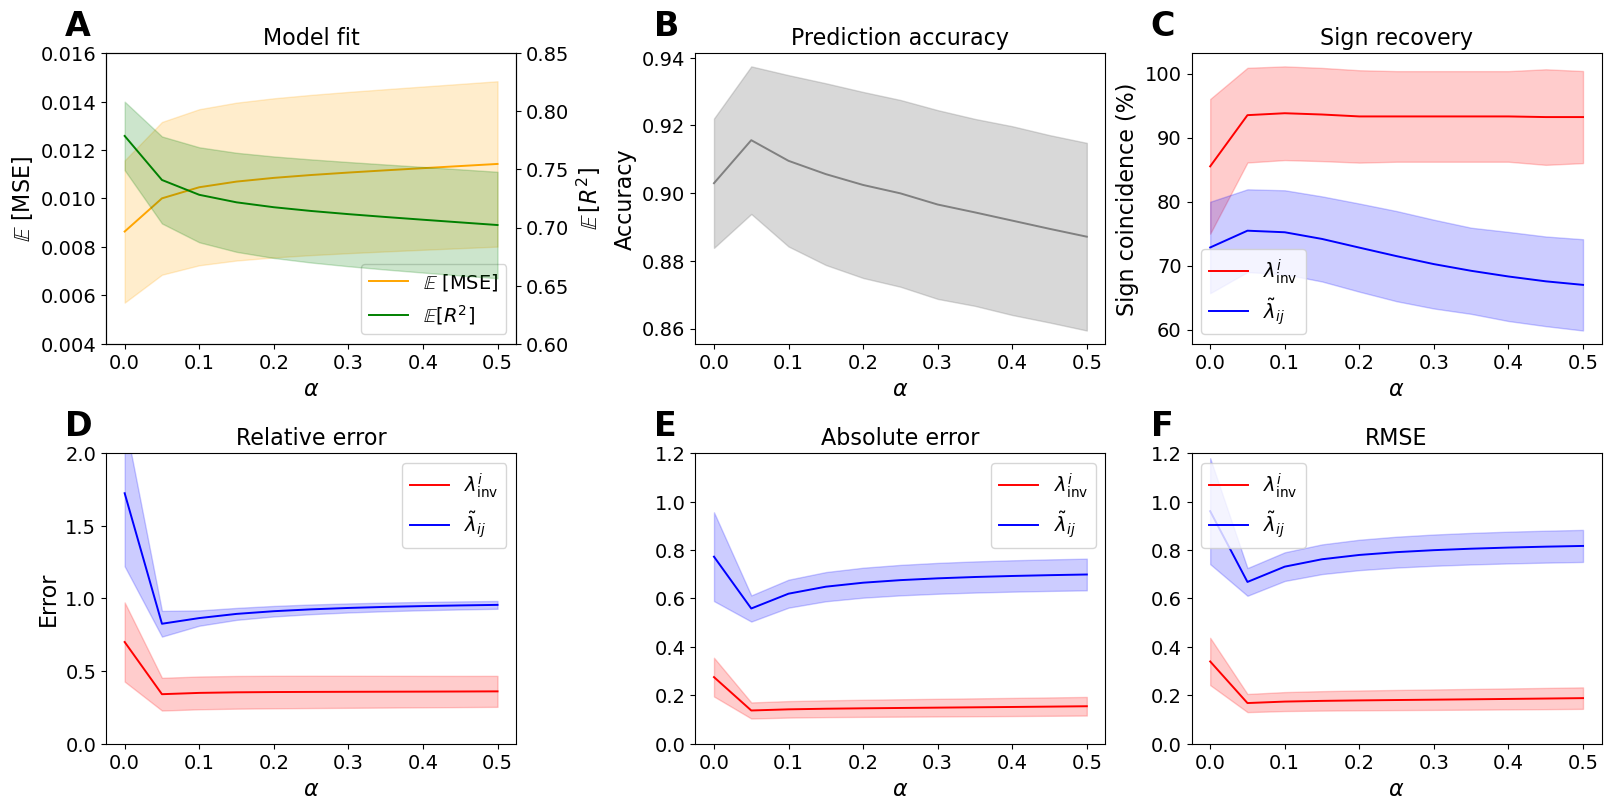

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

# ========== TOP ROW ==========
# (0,0) R2 & MSE
# ========== TOP ROW ==========

# (0,0) R2 and MSE
ax = axes[0, 0]
ax2 = ax.twinx()

res = results["relative"]  # same for all error types

# MSE (orange)
line_mse, = ax.plot(res["alpha"], res["mse_mean"],
                    color="orange", lw=1.4, label=r"$\mathbb{E}$ [MSE]")
ax.fill_between(res["alpha"],
                res["mse_mean"] - res["mse_std"],
                res["mse_mean"] + res["mse_std"],
                color="orange", alpha=0.2)

# R2 (green)
line_r2, = ax2.plot(res["alpha"], res["r2_mean"],
                    color="green", lw=1.4, label=r"$\mathbb{E}[R^2]$")
ax2.fill_between(res["alpha"],
                 res["r2_mean"] - res["r2_std"],
                 res["r2_mean"] + res["r2_std"],
                 color="green", alpha=0.2)

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\mathbb{E}$ [MSE]")
ax2.set_ylabel(r"$\mathbb{E}\,[R^2]$")
ax.legend(handles=[line_mse, line_r2])
ax.set_title("Model fit")
ax.set_ylim(0.004, 0.016)
ax2.set_ylim(0.6, 0.85)


# (0,1) Accuracy (gray)
ax = axes[0, 1]
ax.plot(res["alpha"], res["acc_mean"],
        color="gray", lw=1.4)
ax.fill_between(res["alpha"],
                res["acc_mean"] - res["acc_std"],
                res["acc_mean"] + res["acc_std"],
                color="gray", alpha=0.3)

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Accuracy")
ax.set_title("Prediction accuracy")

# (0,2) Sign coincidence
ax = axes[0, 2]

# Linear (red)
ax.plot(res["alpha"], res["sign_lin_mean"],
        color="red", lw=1.4, label=r"$\lambda_\text{inv}^i$")
ax.fill_between(res["alpha"],
                res["sign_lin_mean"] - res["sign_lin_std"],
                res["sign_lin_mean"] + res["sign_lin_std"],
                color="red", alpha=0.2)

# Quadratic (blue)
ax.plot(res["alpha"], res["sign_quad_mean"],
        color="blue", lw=1.4, label=r"$\tilde{\lambda}_{ij}$")
ax.fill_between(res["alpha"],
                res["sign_quad_mean"] - res["sign_quad_std"],
                res["sign_quad_mean"] + res["sign_quad_std"],
                color="blue", alpha=0.2)

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Sign coincidence (%)")
ax.set_title("Sign recovery")
ax.legend()



# ========== BOTTOM ROW (ERRORS) ==========
titles = {
    "relative": r"Relative error",
    "absolute": r"Absolute error",
    "RMSE": r"RMSE"
}

for j, err in enumerate(errors):
    ax = axes[1, j]
    res = results[err]

    # Linear (red)
    ax.plot(res["alpha"], res["e_lin_mean"],
            color="red", lw=1.4, label=r"$\lambda_\text{inv}^i$")
    ax.fill_between(res["alpha"],
                    res["e_lin_mean"] - res["e_lin_std"],
                    res["e_lin_mean"] + res["e_lin_std"],
                    color="red", alpha=0.2)

    # Quadratic (blue)
    ax.plot(res["alpha"], res["e_quad_mean"],
            color="blue", lw=1.4, label=r"$\tilde{\lambda}_{ij}$")
    ax.fill_between(res["alpha"],
                    res["e_quad_mean"] - res["e_quad_std"],
                    res["e_quad_mean"] + res["e_quad_std"],
                    color="blue", alpha=0.2)

    ax.set_xlabel(r"$\alpha$")
    ax.set_title(titles[err])

    if j == 0:
        ax.set_ylabel("Error")
        ax.set_ylim(0, 2)
    if j == 1:
        ax.set_ylim(0, 1.2)
    if j == 2:
        ax.set_ylim(0, 1.2)
    
    ax.legend()

panel_letters = ["A", "B", "C", "D", "E", "F"]
#panel_letters = ["", "", "", "", "", ""]

def label_panel(ax, letter, fontsize=14, x=-0.1, y=1.15):
    """
    Add a panel letter to the top-left of a subplot.
    ax       : matplotlib Axes
    letter   : str, the letter to place
    fontsize : int, size of the letter
    x, y     : float, position in axes fraction coordinates (0-1)
    """
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=fontsize, fontweight='bold',
            va='top', ha='left')
    
# Flatten axes array for convenience
axes_flat = axes.flatten()

for ax, letter in zip(axes_flat, panel_letters):
    label_panel(ax, letter, fontsize=24)


#fig.savefig("errors_synthetic_data.pdf", bbox_inches="tight")

plt.show()